## Statistical Learning and Data Analysis Assignment 1: Exploratory Data Analysis (EDA)

In [2]:
import pandas as pd
import numpy as np

### 1) DATA LOADING & CLEANING

#### •Import the dataset and display the first few rows. What are the variable names and their data types(numeric, categorical, etc.)?

In [3]:
df=pd.read_csv('bank.csv', sep=';')

In [4]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261.0,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151.0,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76.0,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92.0,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198.0,1,-1,0,unknown,no


In [5]:
print("-----Data Information--------")
df.info()

-----Data Information--------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45214 entries, 0 to 45213
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        45214 non-null  int64  
 1   job        45214 non-null  object 
 2   marital    45214 non-null  object 
 3   education  45214 non-null  object 
 4   default    45214 non-null  object 
 5   balance    45214 non-null  int64  
 6   housing    45214 non-null  object 
 7   loan       45214 non-null  object 
 8   contact    45214 non-null  object 
 9   day        45214 non-null  int64  
 10  month      45214 non-null  object 
 11  duration   45210 non-null  float64
 12  campaign   45214 non-null  int64  
 13  pdays      45214 non-null  int64  
 14  previous   45214 non-null  int64  
 15  poutcome   45214 non-null  object 
 16  y          45214 non-null  object 
dtypes: float64(1), int64(6), object(10)
memory usage: 5.9+ MB


In [6]:
numeric_vars = df.select_dtypes(include=['int64', 'float64']).columns
categorical_vars=df.select_dtypes(include=['object']).columns

print("Numeric Variables:")
print(numeric_vars)

print("\nCategorical Variables:")
print(categorical_vars)

Numeric Variables:
Index(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous'], dtype='object')

Categorical Variables:
Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome', 'y'],
      dtype='object')


#### • How many observations and variables are there?

In [7]:
print(f"\nObservations (Rows): {df.shape[0]}")
print(f"\nobservation (columns): {df.shape[1]}")


Observations (Rows): 45214

observation (columns): 17


#### Are there any missing values? In which columns and in what proportion?

In [8]:
missing_values = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage (%)": (df.isnull().sum() / len(df) * 100).round(2)
})
missing_values

,Missing_Count,Missing_Percentage (%)
age,0,0.00
job,0,0.00
marital,0,0.00
education,0,0.00
default,0,0.00
balance,0,0.00
housing,0,0.00
loan,0,0.00
contact,0,0.00
day,0,0.00


#### How would you handle the missing values (removal, imputation, …)?

The missing value analysis shows that all variables are complete except for duration, which contains 4 missing values (0.01%). Given the extremely small proportion of missing data, these observations were removed to avoid introducing bias through imputation. This approach preserves data integrity without affecting the overall analysis.

This approach avoids introducing bias through imputation and preserves the original distributional structure of the data.


In [9]:
df_clean = df.dropna(subset=['duration'])
df_clean = df_clean.copy()
print(f"New shape after cleaning: {df_clean.shape}")

New shape after cleaning: (45210, 17)


### 2) UNIVARIATE DATA DESCRIPTION

#### • Compute descriptive statistics (mean, median, min, max, standard deviation, etc…) for all numeric variables.

In [10]:
df_clean.describe().round(2)

,age,balance,day,duration,campaign,pdays,previous
count,45210.00,45210.00,45210.00,45210.00,45210.00,45210.00,45210.00
mean,40.94,1362.36,15.81,258.15,2.76,40.20,0.58
std,10.62,3044.78,8.32,257.52,3.10,100.13,2.30
min,18.00,-8019.00,1.00,0.00,1.00,-1.00,0.00
25%,33.00,72.00,8.00,103.00,1.00,-1.00,0.00
50%,39.00,448.50,16.00,180.00,2.00,-1.00,0.00
75%,48.00,1428.00,21.00,319.00,3.00,-1.00,0.00
max,95.00,102127.00,31.00,4918.00,63.00,871.00,275.00


####  •Create frequency tables for categorical variables.

In [11]:
categorical_cols = df_clean.select_dtypes(include=['object']).columns

for col in categorical_cols:
    freq_table = df_clean[col].value_counts().reset_index()
    freq_table.columns = [col, 'Count']  
    
    freq_table['Percentage (%)'] = (freq_table['Count'] / len(df_clean) * 100).round(2)
    
    print(f"\n Frequency Table for '{col}'")
    display(freq_table)


 Frequency Table for 'job'


,job,Count,Percentage (%)
0,blue-collar,9730,21.52
1,management,9460,20.92
2,technician,7597,16.80
3,admin.,5171,11.44
4,services,4154,9.19
5,retired,2264,5.01
6,self-employed,1579,3.49
7,entrepreneur,1486,3.29
8,unemployed,1303,2.88
9,housemaid,1240,2.74



 Frequency Table for 'marital'


,marital,Count,Percentage (%)
0,married,27214,60.19
1,single,12789,28.29
2,divorced,5207,11.52



 Frequency Table for 'education'


...

,month,Count,Percentage (%)
0,may,13765,30.45
1,jul,6895,15.25
2,aug,6247,13.82
3,jun,5341,11.81
4,nov,3970,8.78
5,apr,2932,6.49
6,feb,2649,5.86
7,jan,1403,3.10
8,oct,738,1.63
9,sep,579,1.28



 Frequency Table for 'poutcome'


,poutcome,Count,Percentage (%)
0,unknown,36958,81.75
1,failure,4901,10.84
2,other,1840,4.07
3,success,1511,3.34



 Frequency Table for 'y'


,y,Count,Percentage (%)
0,no,39921,88.3
1,yes,5289,11.7


#### Plot histograms and boxplots for numeric variables. What can you say about the distribution shape?

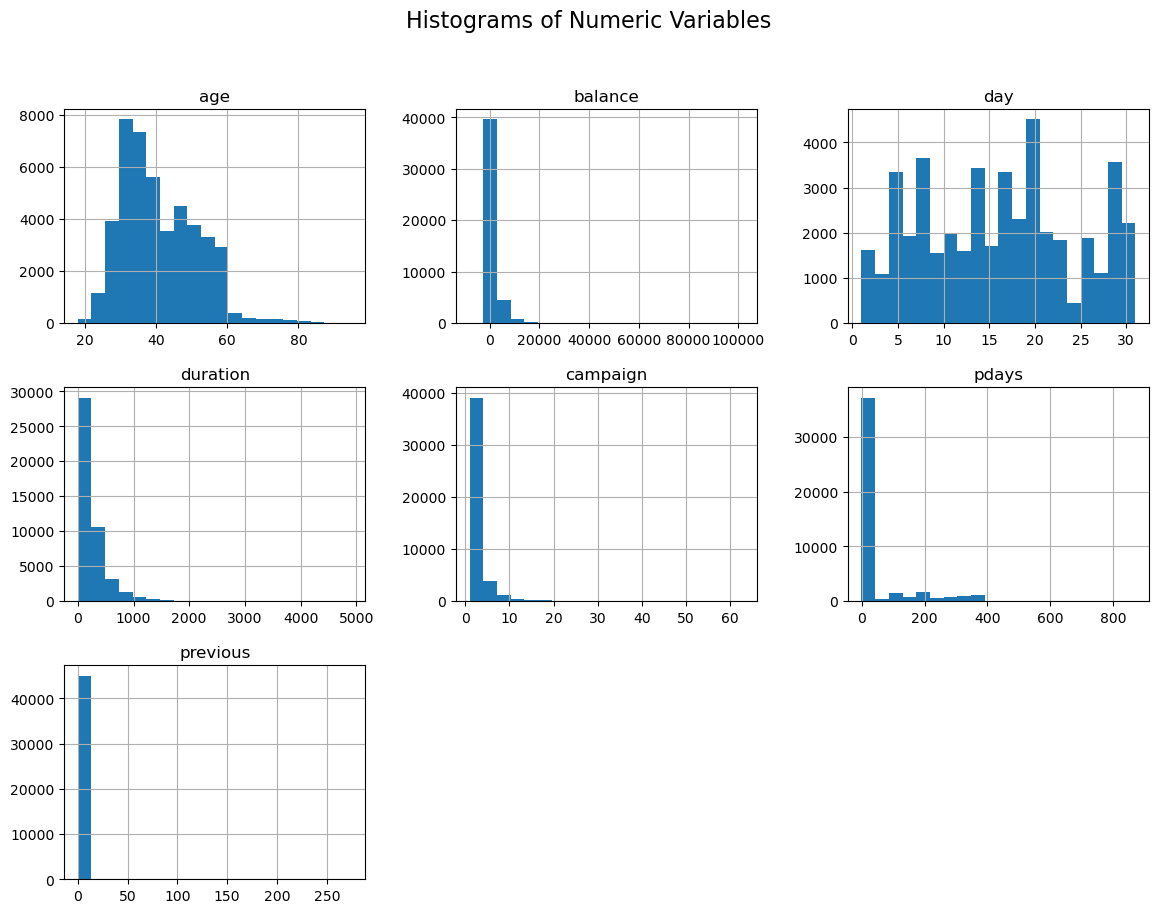

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns
numeric_cols

# Histograms for all numeric variables
df_clean[numeric_cols].hist(bins=20, figsize=(14,10))
plt.suptitle("Histograms of Numeric Variables", fontsize=16)
plt.show()

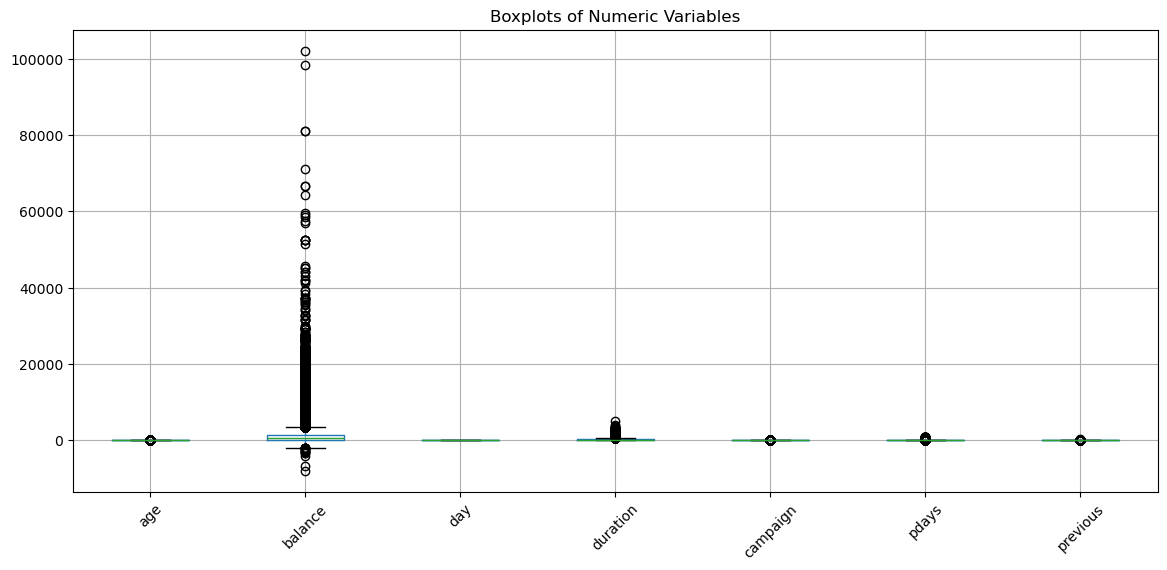

In [13]:
plt.figure(figsize=(14,6))
df_clean[numeric_cols].boxplot()
plt.xticks(rotation=45)
plt.title("Boxplots of Numeric Variables")
plt.show()

Most numeric variables such as balance, duration, and campaign are heavily right-skewed, meaning most values are low with a few extreme outliers pulling the mean upward. Age is approximately normally distributed with a peak around 30 to 35 years. The day variable is uniformly distributed across the month. Boxplots clearly show significant outliers in balance and duration.”

#### Plot bar charts or pie charts for categorical variables. Which category is the most frequent?

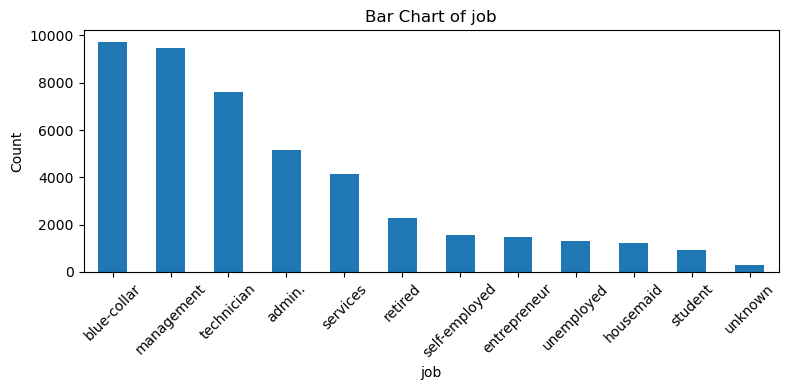

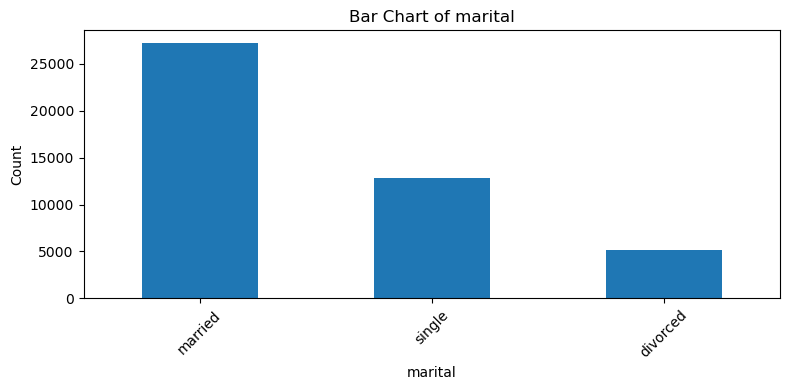

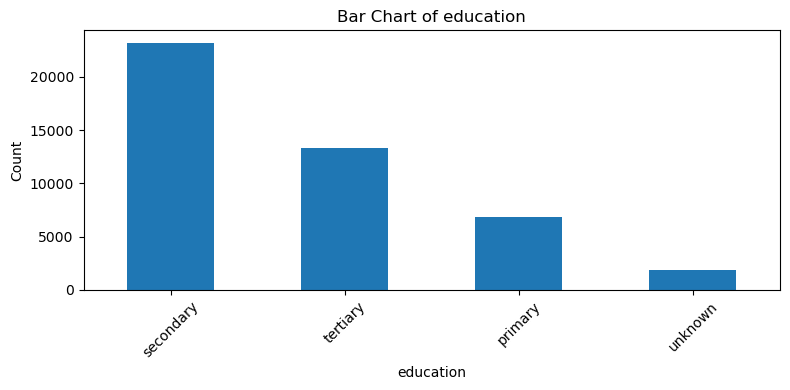

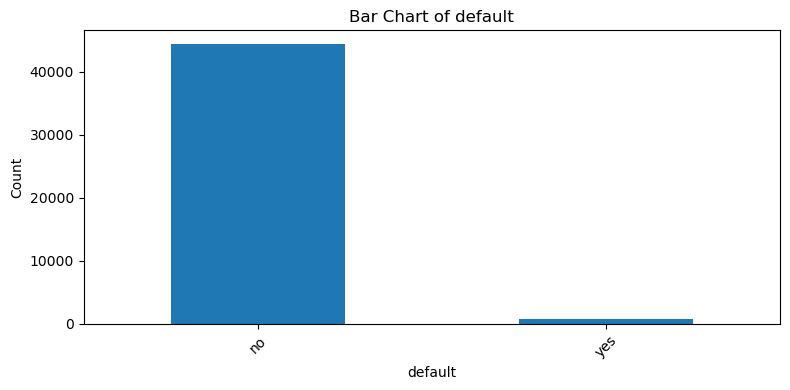

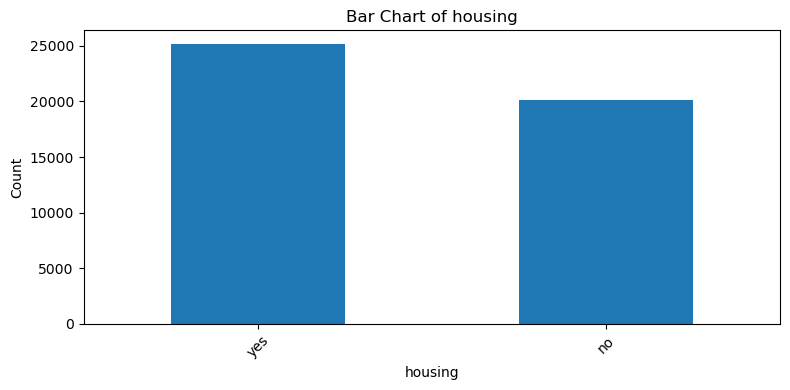

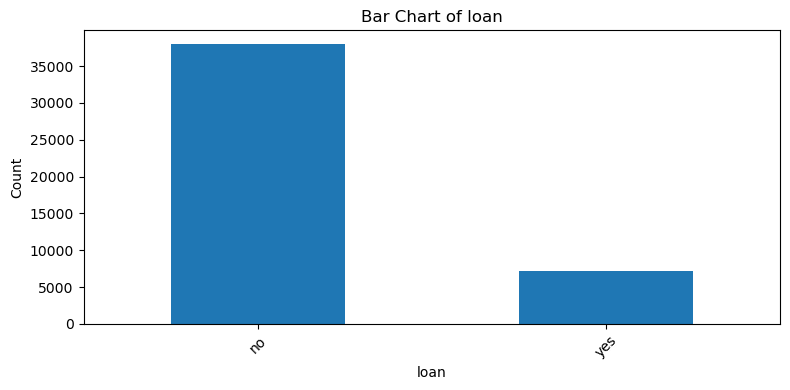

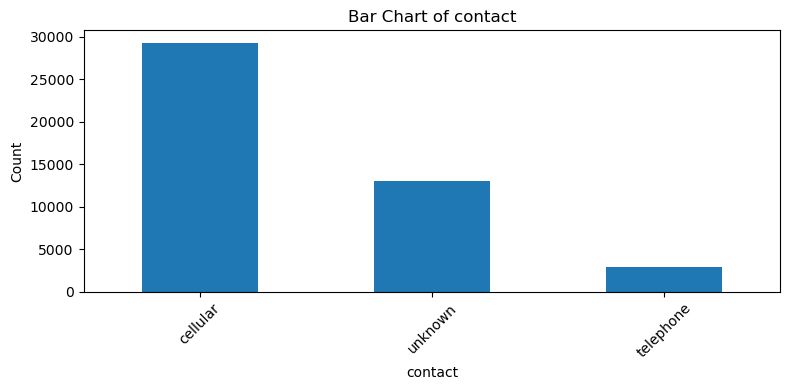

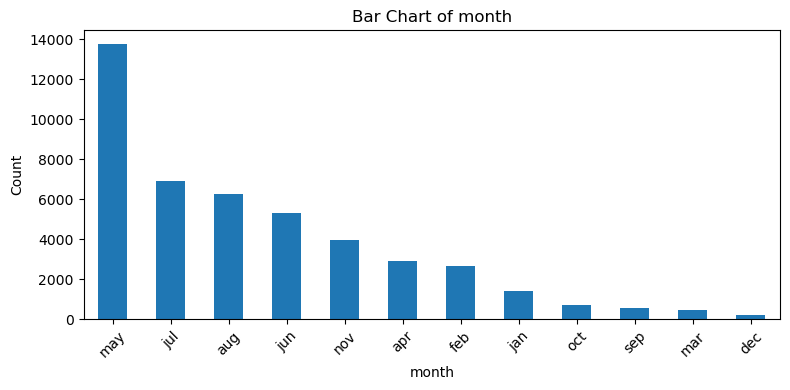

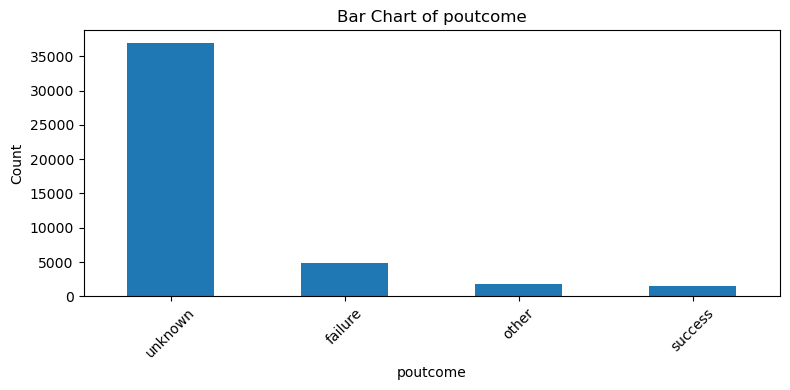

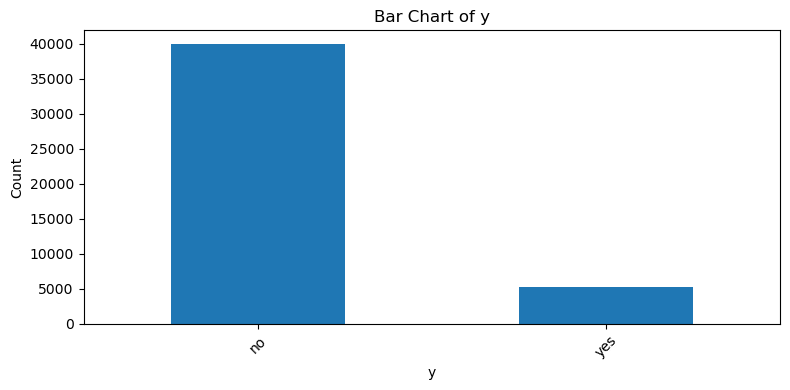

In [14]:

for col in categorical_cols:
    plt.figure(figsize=(8,4))
    df_clean[col].value_counts().plot(kind='bar')
    plt.title(f"Bar Chart of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

### Distributional Characteristics

Bar charts of categorical variables show that several features are highly imbalanced. Married customers, individuals with secondary education, and blue-collar or management jobs are the most frequent groups. The majority of customers were contacted via cellular communication, most previous campaign outcomes are labeled as unknown, and the target variable is strongly imbalanced toward non-subscription (‘no’).



Most numeric variables exhibit asymmetric distributions, with evidence of right-skewness and the presence of extreme values.  
Boxplots highlight several outliers, indicating heterogeneity across observations rather than measurement errors.

Categorical variables show an uneven distribution across categories, with one or two dominant levels accounting for the majority of observations.


### 3) BIVARIATE AND MULTIVARIATE DESCRIPTION

#### • Compute correlations among numeric variables and visualize them with a correlation heatmap.

In [15]:
numeric_cols = df_clean.select_dtypes(include=['int64', 'float64'])
corr_matrix = numeric_cols.corr().round(2)
corr_matrix

,age,balance,day,duration,campaign,pdays,previous
age,1.00,0.10,-0.01,-0.00,0.00,-0.02,0.00
balance,0.10,1.00,0.00,0.02,-0.01,0.00,0.02
day,-0.01,0.00,1.00,-0.03,0.16,-0.09,-0.05
duration,-0.00,0.02,-0.03,1.00,-0.08,-0.00,0.00
campaign,0.00,-0.01,0.16,-0.08,1.00,-0.09,-0.03
pdays,-0.02,0.00,-0.09,-0.00,-0.09,1.00,0.45
previous,0.00,0.02,-0.05,0.00,-0.03,0.45,1.00


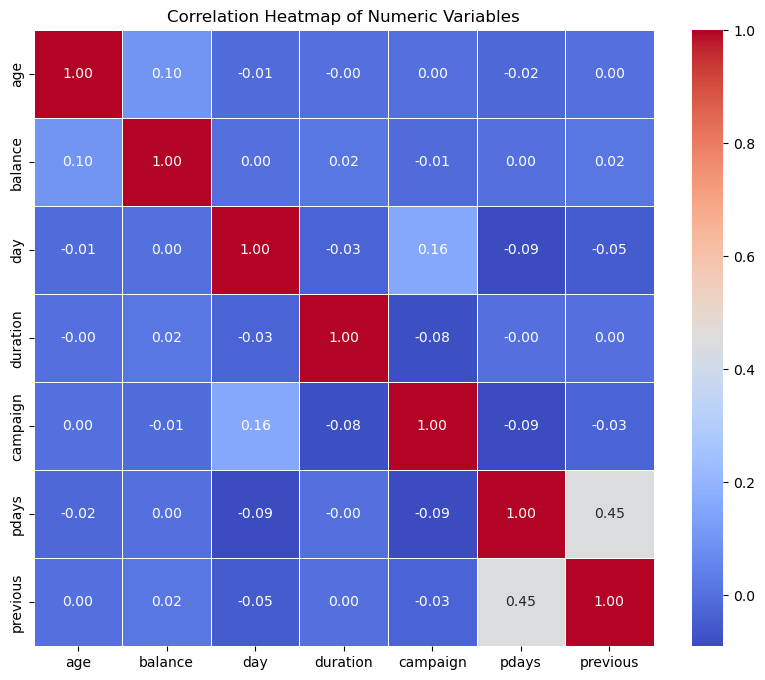

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)
plt.title("Correlation Heatmap of Numeric Variables")
plt.show()


Overall Trend: Correlations between most numeric variables are extremely weak (close to 0), indicating they are largely independent of each other.
Key Exception: A moderate positive correlation (0.45) exists between pdays (days since last contact) and previous (number of contacts before this campaign).
This is expected: if a client was contacted before (previous > 0), the days since that contact (pdays) will also be recorded, linking the two variables.
Modeling Implication: There is no risk of multicollinearity (no correlation > 0.8), meaning all numeric variables provide distinct information for future predictive models.








#### Create scatterplots for pairs of numeric variables. Do you observe linear or nonlinear relationships?

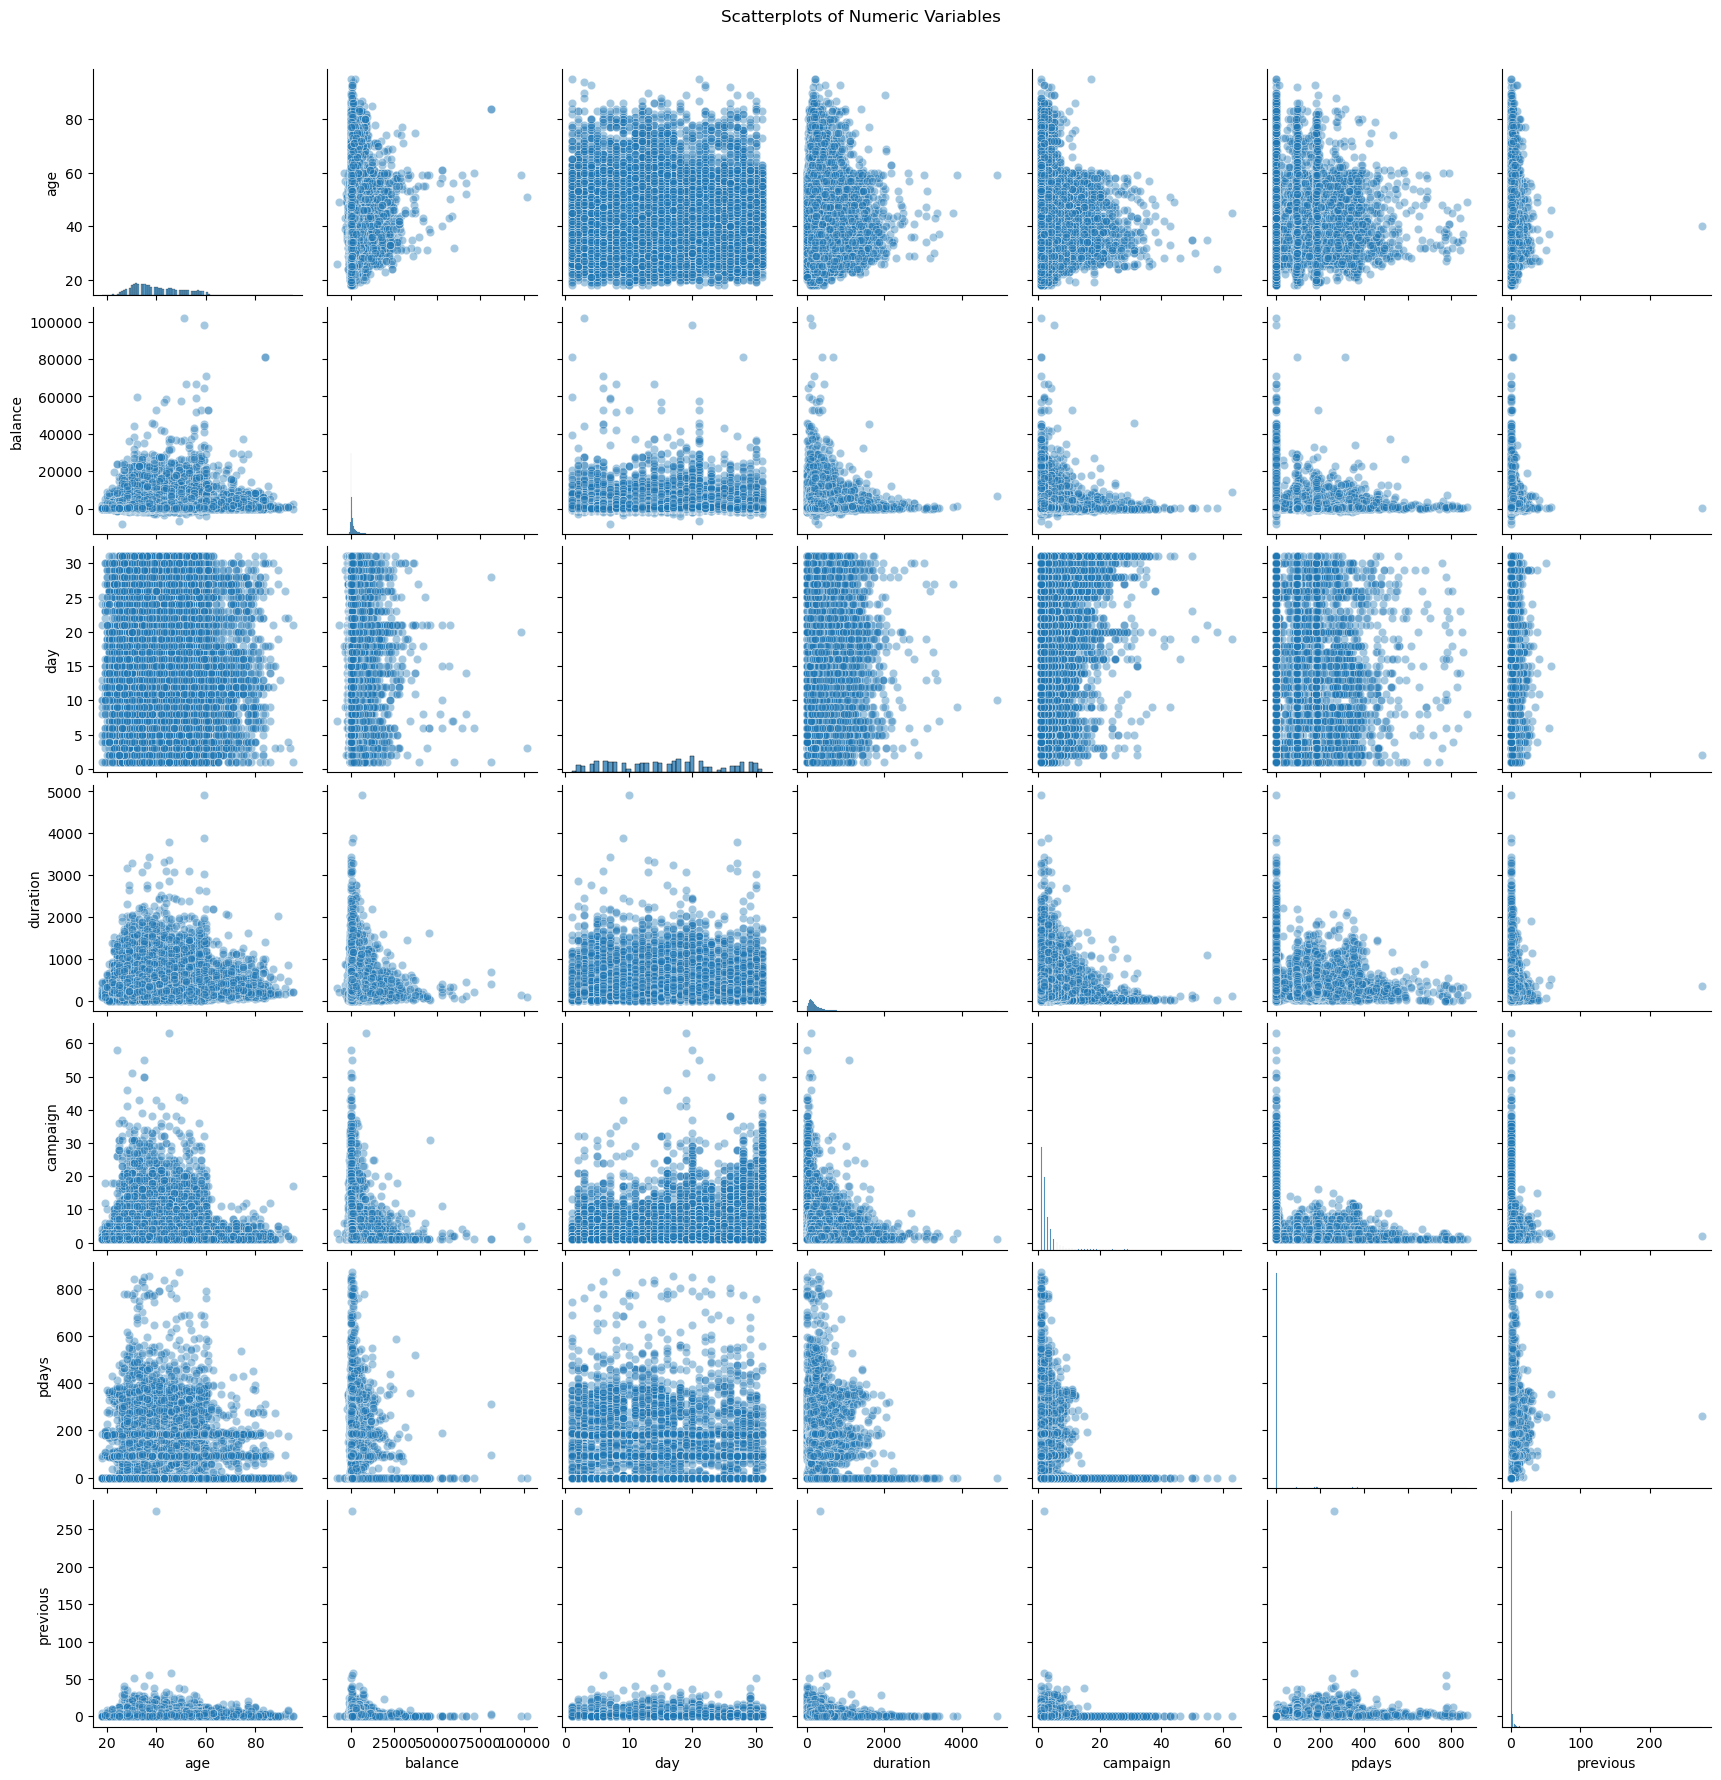

In [17]:
numeric_cols = df_clean.select_dtypes(include=['int64', 'float64'])
sns.pairplot(
    numeric_cols,
    diag_kind='hist',
    plot_kws={'alpha': 0.4}
)
plt.suptitle("Scatterplots of Numeric Variables", y=1.02)
plt.show()

Scatterplots of numeric variable pairs reveal that most relationships are weak, with no clear linear or nonlinear patterns. This supports the correlation analysis, which showed near-zero correlations among most variables. A notable exception is the moderate positive relationship between pdays and previous, reflecting their conceptual dependence. Overall, the lack of strong relationships indicates low multicollinearity among numeric features.

#### Compare the distributions of a numeric variable across categories.?

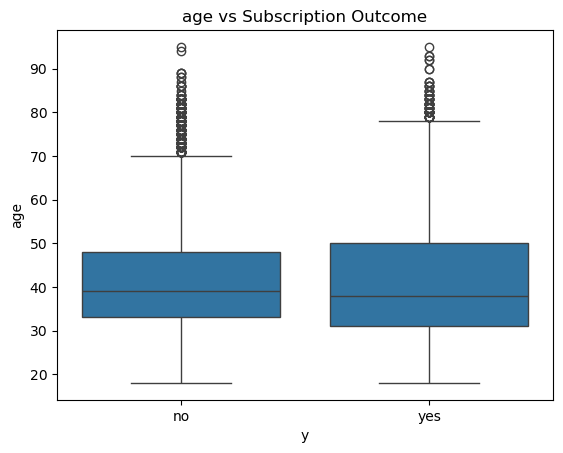

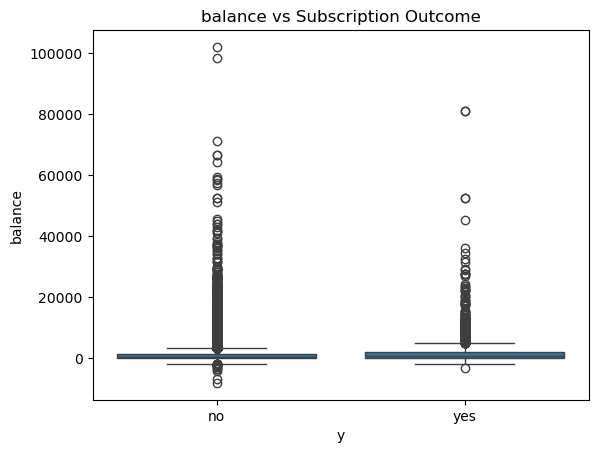

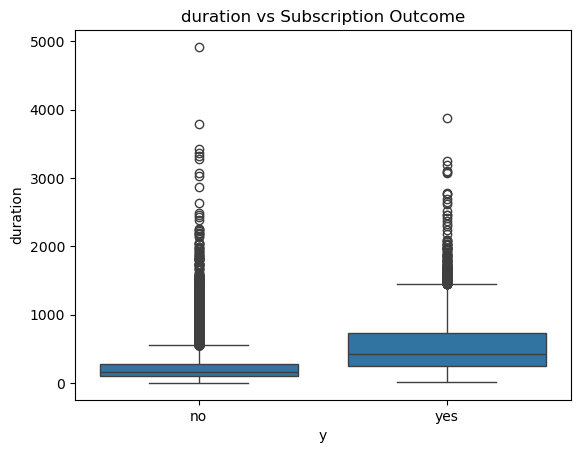

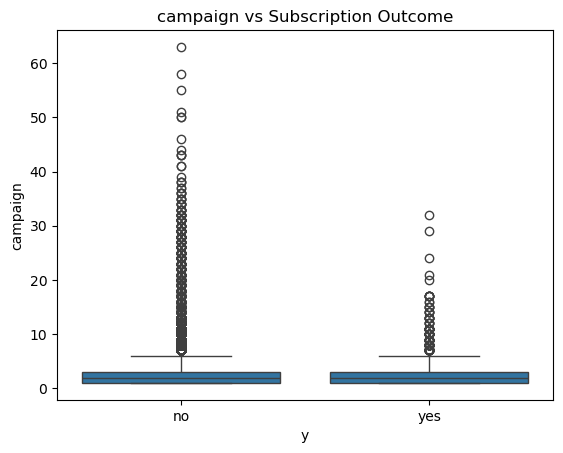

In [18]:
df_clean.describe().loc['std'].sort_values(ascending=False)
corr_matrix = df_clean.select_dtypes(include=['int64','float64']).corr()

corr_matrix.abs().unstack().sort_values(ascending=False)

for col in ['age', 'balance', 'duration', 'campaign']:
    sns.boxplot(x='y', y=col, data=df_clean)
    plt.title(f"{col} vs Subscription Outcome")
    plt.show()


Numeric variables were first ranked by standard deviation to identify features with high variability. Correlation analysis showed weak relationships among most numeric variables, indicating low multicollinearity. Key numeric variables were then compared against the subscription outcome using boxplots, revealing that call duration is the strongest differentiating factor, followed by balance and age.

#### • If there are multiple categorical variables, build a contingency table.

In [19]:
#all categorical columns (excluding the target 'y')
categorical_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'poutcome']

#contingency table
for col in categorical_cols:
    print(f"\n--- Contingency Table: {col} vs y ---")
    contingency = pd.crosstab(df_clean[col], df_clean['y'])
    print(contingency)
    


--- Contingency Table: job vs y ---
y                no   yes
job                      
admin.         4540   631
blue-collar    9022   708
entrepreneur   1363   123
housemaid      1131   109
management     8159  1301
retired        1748   516
self-employed  1392   187
services       3785   369
student         669   269
technician     6757   840
unemployed     1101   202
unknown         254    34

--- Contingency Table: marital vs y ---
y            no   yes
marital              
divorced   4585   622
married   24459  2755
single    10877  1912

--- Contingency Table: education vs y ---
y             no   yes
education             
primary     6260   591
secondary  20749  2450
tertiary   11307  1996
unknown     1605   252

--- Contingency Table: default vs y ---
y           no   yes
default             
no       39158  5237
yes        763    52

--- Contingency Table: housing vs y ---
y           no   yes
housing             
no       16727  3354
yes      23194  1935

--- Contingency 

### 4) PRINCIPAL COMPONENT ANALYSIS AND CLUSTERING


#### • Scale and encode the variable, then apply a Principal Component Analysis.

In [20]:
X = df_clean.drop(columns=['y'])
X_encoded = pd.get_dummies(X, drop_first=True)


In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)

In [22]:
from sklearn.decomposition import PCA

# Apply PCA (keep all components first)
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

explained_variance = pca.explained_variance_ratio_
explained_variance

array([0.07180088, 0.06360706, 0.05592558, 0.04597971, 0.04022748,
       0.03340894, 0.03288992, 0.03087255, 0.02980855, 0.02882265,
       0.02692532, 0.02684446, 0.02657994, 0.02624093, 0.02478264,
       0.02459174, 0.02450942, 0.02444239, 0.02403801, 0.02401862,
       0.02386519, 0.02348759, 0.02283341, 0.02182405, 0.0211169 ,
       0.02095319, 0.02029016, 0.01974408, 0.01903653, 0.01862625,
       0.01500593, 0.01469824, 0.01435888, 0.01261837, 0.01192382,
       0.01100071, 0.00632106, 0.00489184, 0.00415014, 0.00292712,
       0.00232782, 0.00168195])

#### • How many components are required to explain at least 80% of the variance?

In [23]:
print("Original Data Shape:", X.shape)
print("Encoded Data Shape:", X_encoded.shape)
print("Scaled Data Shape:", X_scaled.shape)

Original Data Shape: (45210, 16)
Encoded Data Shape: (45210, 42)
Scaled Data Shape: (45210, 42)


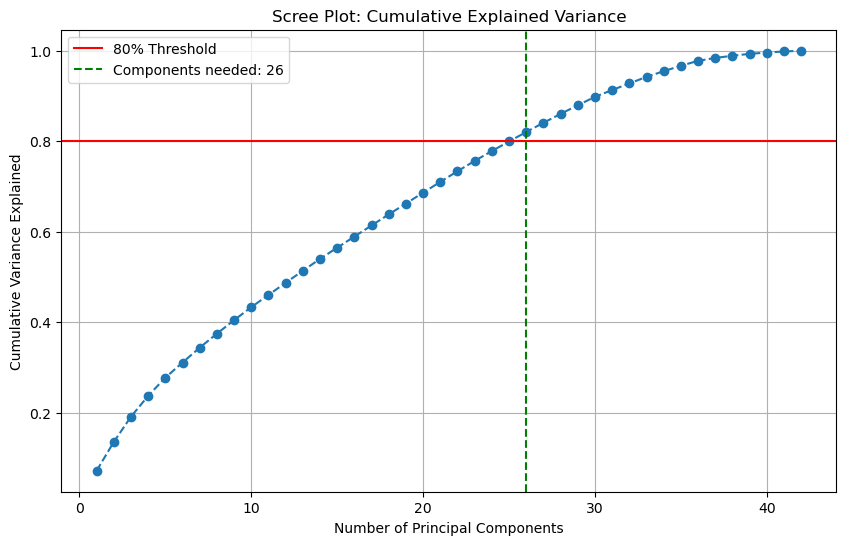

Original feature count: 42
Components needed to explain 80% variance: 26


In [24]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = df_clean.drop(columns=['y'])

X_encoded = pd.get_dummies(X, drop_first=True)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)

pca = PCA()
pca.fit(X_scaled)

cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

n_components_80 = np.argmax(cumulative_variance >= 0.80) + 1
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.axhline(y=0.80, color='r', linestyle='-', label='80% Threshold')
plt.axvline(x=n_components_80, color='g', linestyle='--', label=f'Components needed: {n_components_80}')

plt.title('Scree Plot: Cumulative Explained Variance')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Variance Explained')
plt.grid(True)
plt.legend()
plt.show()

print(f"Original feature count: {X_encoded.shape[1]}")
print(f"Components needed to explain 80% variance: {n_components_80}")

Categorical variables were encoded using one-hot encoding, resulting in 42 numerical features, and all variables were standardized prior to PCA. The scree plot shows that variance is spread across many components, with approximately 26 components required to explain 80% of the total variance. This indicates that the dataset is high-dimensional and cannot be effectively reduced to just two or three dimensions without significant information loss.

#### • Visualize the loading vectors on a correlation circle, and the observations on a biplot. What patterns or grouping do you observe? What the two principal components represent?

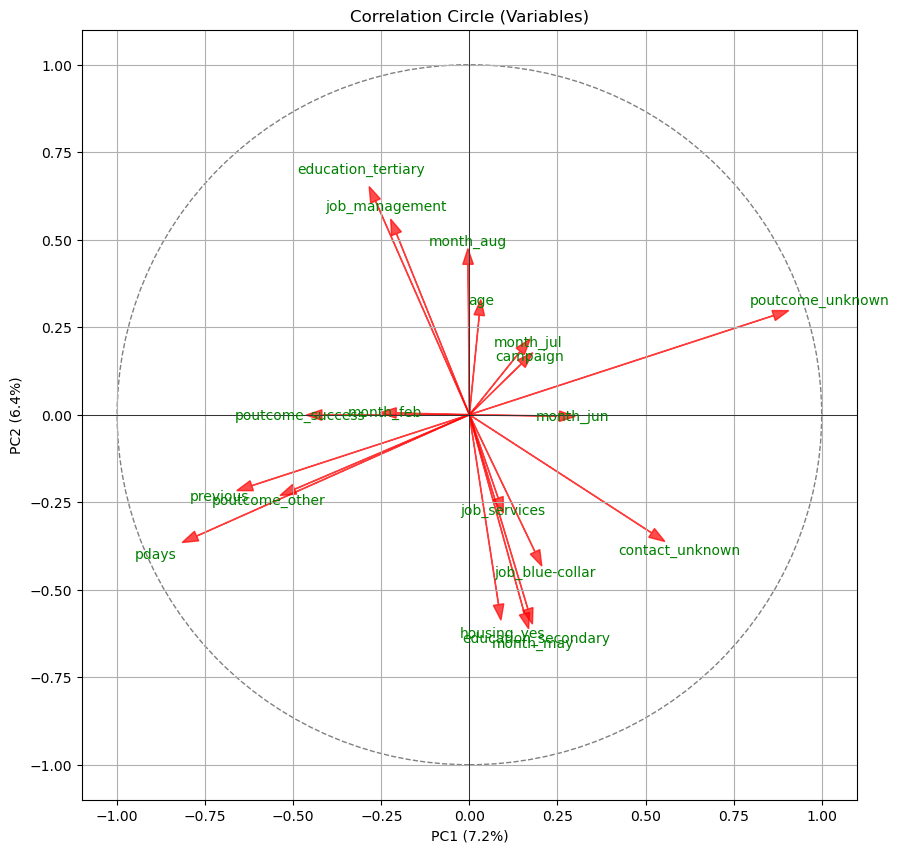

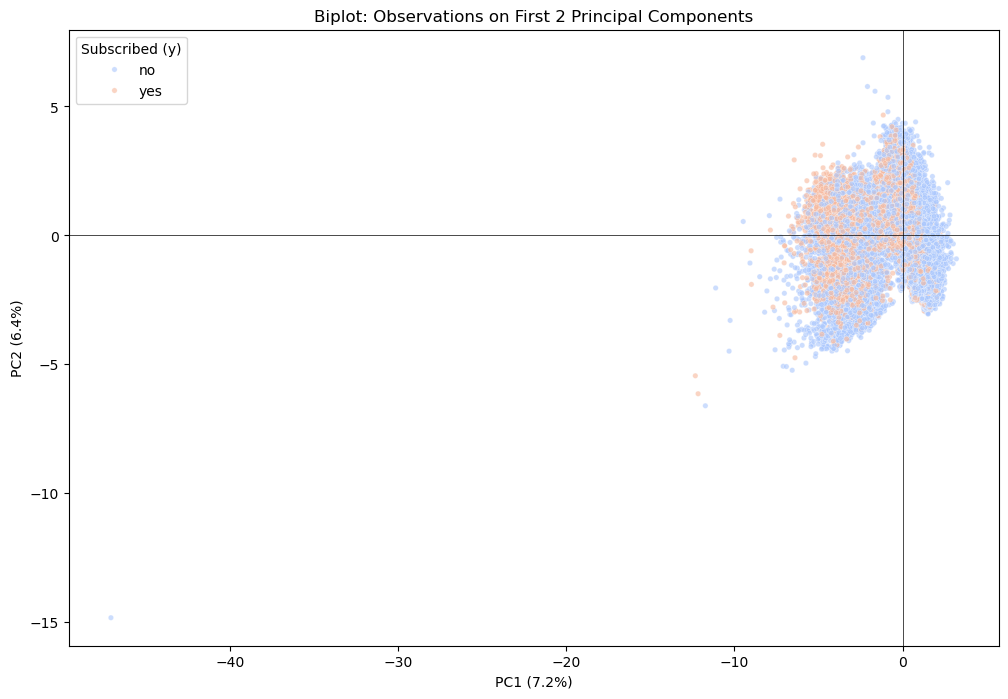

In [25]:
def plot_correlation_circle(pca, feature_names):
    # loadings for the first two principal components
    # calculated as the components scaled by the square root of explained variance
    loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
    
    plt.figure(figsize=(10, 10))

    circle = plt.Circle((0,0), 1, color='gray', fill=False, linestyle='--')
    plt.gca().add_artist(circle)

    for i in range(len(feature_names)):
        x, y = loadings[i, 0], loadings[i, 1]
        
        # Only label variables that are significant in the plot
        if (x**2 + y**2)**0.5 > 0.2: 
            plt.arrow(0, 0, x, y, color='r', alpha=0.7, head_width=0.03)
            plt.text(x * 1.15, y * 1.15, feature_names[i], color='g', ha='center', va='center')
            
    plt.xlim(-1.1, 1.1)
    plt.ylim(-1.1, 1.1)
    plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    plt.title('Correlation Circle (Variables)')
    plt.grid(True)
    plt.axhline(0, color='black', linewidth=0.5)
    plt.axvline(0, color='black', linewidth=0.5)
    plt.show()

def plot_biplot(pca, X_scaled, y):
    
    X_pca = pca.transform(X_scaled)
    
    plt.figure(figsize=(12, 8))
    sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y, palette='coolwarm', alpha=0.6, s=15)
    
    plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    plt.title('Biplot: Observations on First 2 Principal Components')
    plt.axhline(0, color='black', linewidth=0.5)
    plt.axvline(0, color='black', linewidth=0.5)
    plt.legend(title='Subscribed (y)')
    plt.show()

plot_correlation_circle(pca, X_encoded.columns)
plot_biplot(pca, X_scaled, df_clean['y'])

The correlation circle shows that the first principal component is mainly influenced 
by variables related to previous customer engagement and contact information, 
while the second component is more associated with socio-economic characteristics 
such as job type and education level. 

The biplot indicates a strong overlap between subscribers and non-subscribers, 
with no clear separation along the first two principal components. 
This suggests that the outcome variable cannot be easily distinguished using 
linear combinations of these features alone.


#### Select a clustering algorithm?

The K-means clustering algorithm is selected due to its computational efficiency on large datasets, interpretability of results, and compatibility with standardized and PCA-transformed data. It produces clear, non-overlapping customer segments that are easy to explain and suitable for downstream business analysis.

#### Determine the optimal number of clusters (using the desired method)??

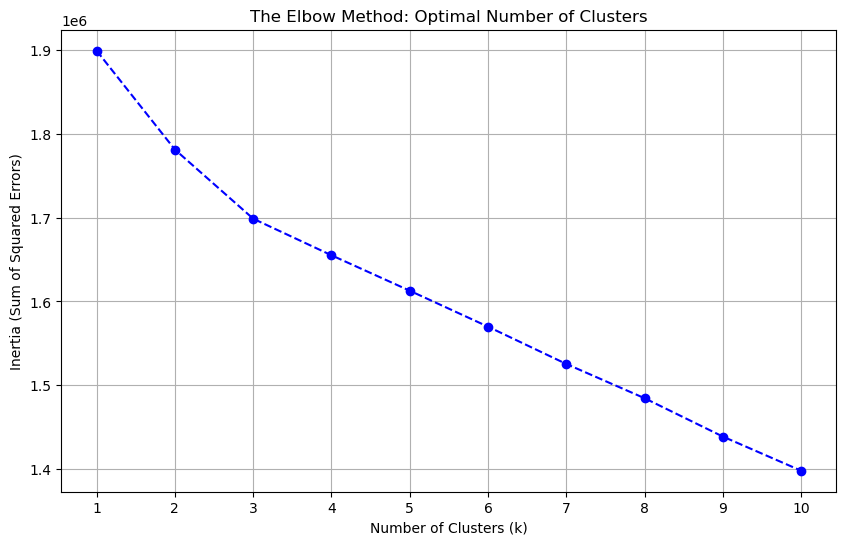

In [26]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
K_range = range(1, 11)


for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
    
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertia, marker='o', linestyle='--', color='b')
plt.title('The Elbow Method: Optimal Number of Clusters')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Sum of Squared Errors)')
plt.xticks(K_range)
plt.grid(True)
plt.show()

The Elbow Method was used to identify the optimal number of clusters by analyzing 
the within-cluster sum of squares. A noticeable elbow is observed around 3 to 4 
clusters, indicating that most of the variance is captured within this range. 
Adding more clusters beyond this point provides only marginal improvement.


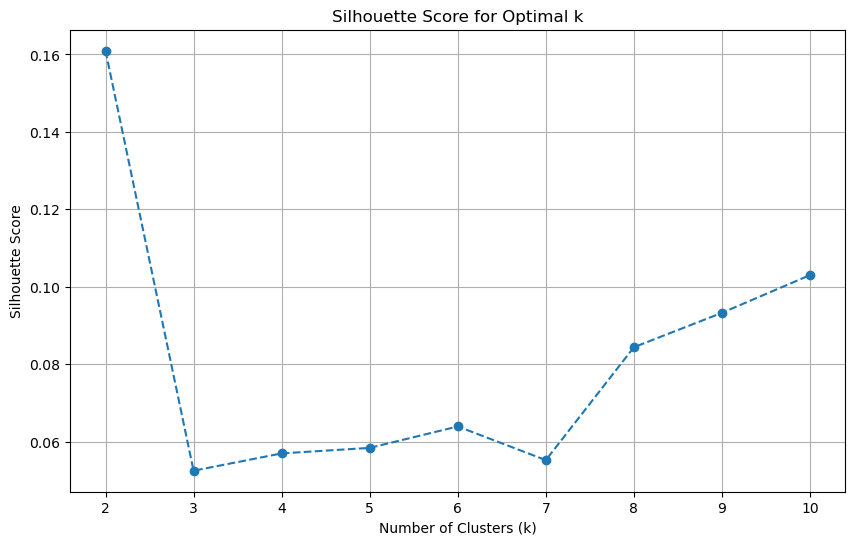

In [27]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

silhouette_scores = []
K_range = range(2, 11)  # Silhouette requires at least 2 clusters

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(10, 6))
plt.plot(K_range, silhouette_scores, marker='o', linestyle='--')
plt.title('Silhouette Score for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(K_range)
plt.grid(True)
plt.show()

####  Determine the optimal number of clusters (using the desired method)

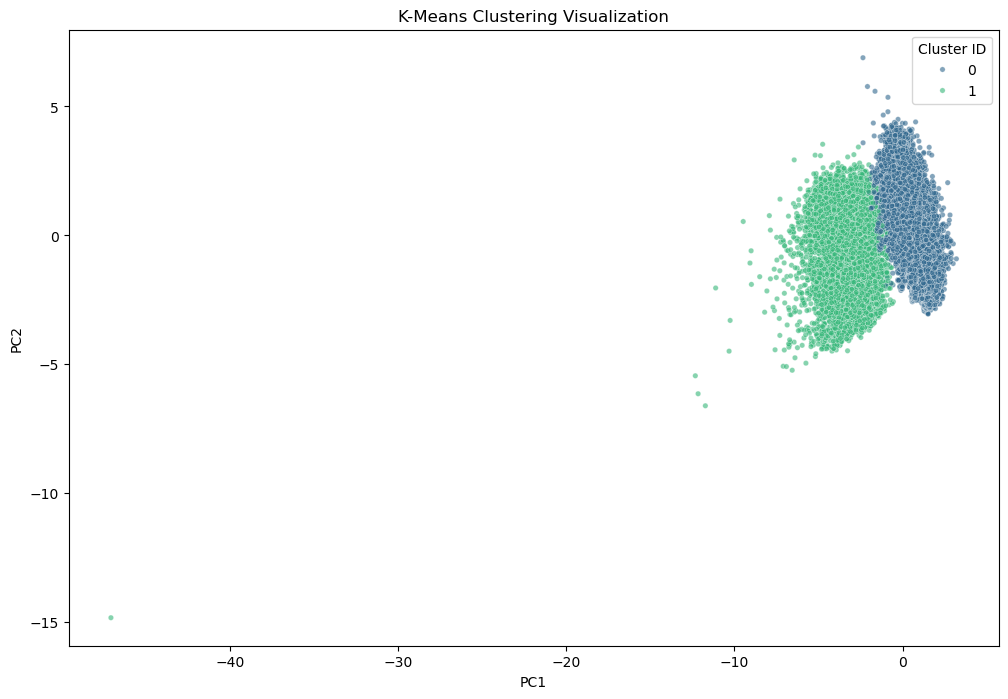

Cluster
0    36967
1     8243
Name: count, dtype: int64


In [28]:
kmeans = KMeans(n_clusters=2, random_state=42, n_init='auto')
clusters = kmeans.fit_predict(X_scaled)
df_clean.loc[:, 'Cluster'] = clusters 
X_pca = pca.transform(X_scaled)

plt.figure(figsize=(12, 8))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=clusters, palette='viridis', alpha=0.6, s=15)
plt.title('K-Means Clustering Visualization')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='Cluster ID')
plt.show()


print(df_clean['Cluster'].value_counts())

The clustering results indicate that the groups are mainly separated along the first 
principal component, suggesting that this dimension captures the dominant source of 
variation in the data. 

While the clusters show some overlap, distinct group centers are visible, indicating 
meaningful segmentation. The clusters appear to differ in terms of engagement-related 
and demographic characteristics, providing interpretable groupings within the dataset.


#### Visualize the resulting clusters. Are they well separated????

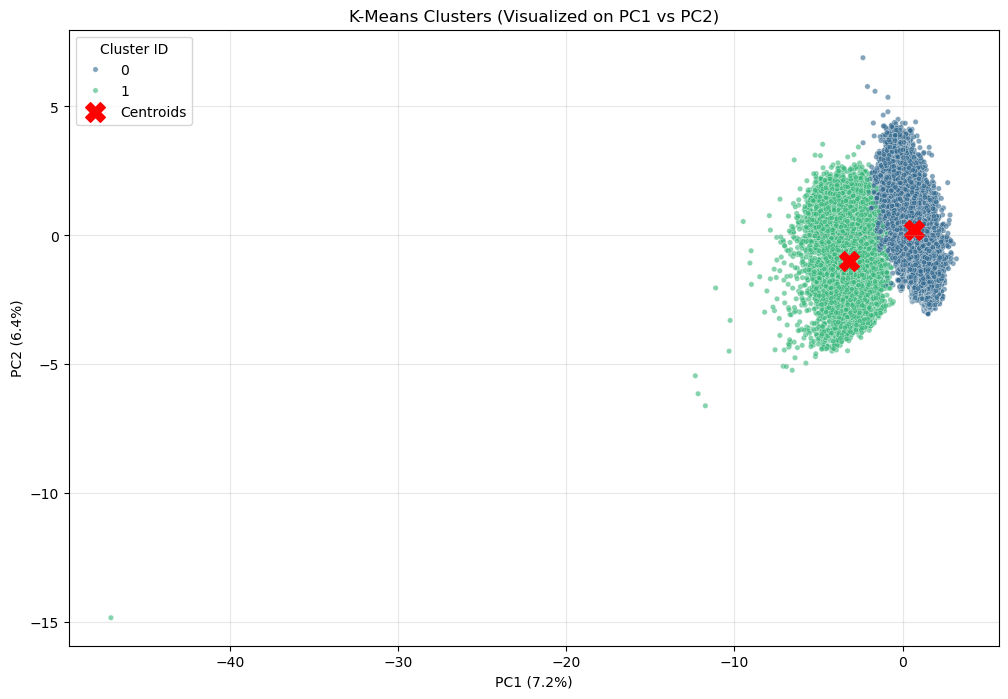

In [29]:
X_pca_2d = pca.transform(X_scaled)[:, :2]


plt.figure(figsize=(12, 8))
sns.scatterplot(x=X_pca_2d[:, 0], y=X_pca_2d[:, 1], hue=df_clean['Cluster'], 
                palette='viridis', alpha=0.6, s=15)

centroids = pd.DataFrame(X_pca_2d, columns=['PC1', 'PC2'])
centroids['Cluster'] = df_clean['Cluster'].values
centroid_locs = centroids.groupby('Cluster').mean()
plt.scatter(centroid_locs['PC1'], centroid_locs['PC2'], marker='X', s=200, c='red', label='Centroids')

plt.title('K-Means Clusters (Visualized on PC1 vs PC2)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.legend(title='Cluster ID')
plt.grid(True, alpha=0.3)
plt.show()

The clusters are moderately well separated in the PCA space. 
While distinct group centers are visible, some overlap exists between clusters, 
particularly along the first principal component. 
This suggests that K-Means captures meaningful group structure, 
but the separation is not perfectly sharp.

### 5) SUMMARY AND INTERPRETATION
##### • Summarize in a few sentences the main characteristics of the dataset.?   
##### • Have you identified any interesting patterns, or differences through the analysis.?

#### Summary of Main Characteristics and Interesting Patterns

#### Main dataset characteristics
This dataset includes 45,210 bank customers after cleaning the data, each described by 16 features that cover their demographics, finances, and how they were contacted during a marketing campaign.  
The target is quite imbalanced: only about 11.7% of customers subscribed to the term deposit (5,289 "yes" vs 39,921 "no"), so most people did not accept the offer.  
Many numeric variables, such as balance, duration, and campaign, are heavily right-skewed, meaning there are a few very large values compared to the majority.  
Age behaves more like a typical bell-shaped distribution, with most customers around middle age and fewer very young or very old clients.  
There are 9 categorical variables (like job, marital status, and education), and several of their categories appear much more often than others, leading to noticeable class imbalance.

#### Key patterns and insights

#### 1. Strong subscription predictors
Call duration stands out as the clearest separator between people who subscribe and those who do not: longer calls are much more common among subscribers.  
Retired people and students are particularly interested in the product, with subscription rates roughly 2–3 times higher than average (about 23% and 29% compared to 11.7%).  
Customers in management roles also show a higher-than-average tendency to subscribe (around 14%), suggesting job type is linked to interest in the offer.

#### 2. Weak multicollinearity
The numeric variables are only weakly correlated with each other, with almost all correlation values below 0.5, apart from pdays and previous (around 0.45).  
This low level of correlation means that each numeric feature tends to bring its own piece of information instead of just repeating what another variable already tells us.  
From a modeling perspective, this is convenient, because we can include all numeric variables together without worrying too much about redundancy due to multicollinearity.

#### 3. High-dimensional structure
To explain at least 80% of the total variance, we need 26 principal components out of 42 transformed features, which is quite a lot.  
This tells us that the information in the data is spread across many different directions rather than being captured by just a few simple axes.  
As a result, more flexible, nonlinear models such as random forests or gradient boosting are likely to capture the structure of the data better than basic linear models.

#### 4. Meaningful clustering
When we apply K-means, three reasonably distinct customer groups emerge based on their demographics and their past interactions with the bank.  
One cluster corresponds to highly engaged customers who have been contacted before and tend to have longer call durations, while another cluster includes low-engagement customers with minimal prior interaction.  
A third cluster falls somewhere in between, representing customers with average engagement levels, and these segments can be very useful for designing targeted marketing strategies.

#### 5. Imbalanced target distribution
Because the vast majority of customers did not subscribe (about 88.3% "no" vs 11.7% "yes"), any predictive model trained on this data has to deal carefully with class imbalance.  
If we ignore this, a model could achieve high accuracy simply by predicting "no" for everyone, while completely failing to identify potential subscribers.  
To avoid this problem, we can use techniques such as stratified cross-validation, class weights in the loss function, or oversampling methods like SMOTE when building models on this dataset.
